In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(2612)

In [12]:
def euclidean_projection_simplex(v):
    """Projeção no simplex {x >= 0, sum x = 1}"""
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.where(u > (cssv - 1) / (np.arange(len(v)) + 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    return np.maximum(v - theta, 0)

def bregman_projection_simplex(v):
    return v/v.sum()

In [13]:
# Parâmetros do experimento
dims = np.logspace(1, 5, 20, dtype=int)  # 10 valores entre 10 e 10000
num_trials = 50                          # repetições por dimensão

# Armazenamento dos resultados
mean_times_euclidean = []
std_times_euclidean = []
mean_times_bregman = []
std_times_bregman = []

# Loop principal
rng = np.random.default_rng()

for n in dims:
    times_euclid = []
    times_breg = []
    for _ in range(num_trials):
        v = rng.random(n)

        # Euclidean projection
        start = time.perf_counter()
        euclidean_projection_simplex(v)
        times_euclid.append(time.perf_counter() - start)

        # Bregman projection
        start = time.perf_counter()
        bregman_projection_simplex(v)
        times_breg.append(time.perf_counter() - start)

    mean_times_euclidean.append(np.mean(times_euclid))
    std_times_euclidean.append(np.std(times_euclid))
    mean_times_bregman.append(np.mean(times_breg))
    std_times_bregman.append(np.std(times_breg))

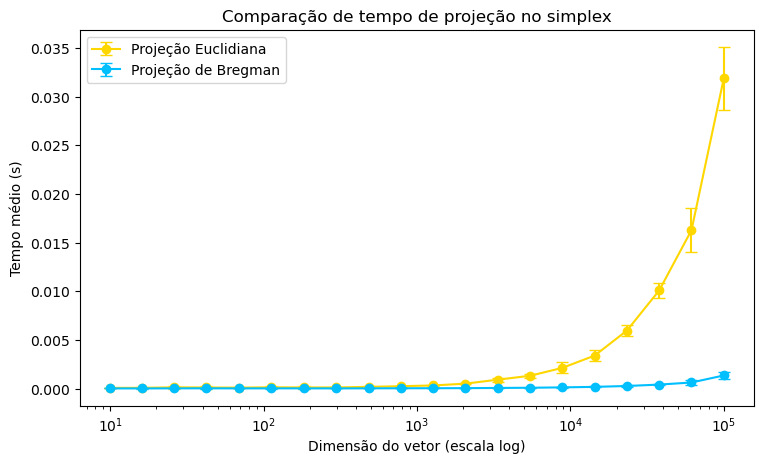

In [14]:
# Plot
plt.figure(figsize=(8,5))
plt.errorbar(dims, mean_times_euclidean, yerr=std_times_euclidean, 
             fmt='o-', color="gold", capsize=4, label="Projeção Euclidiana")
plt.errorbar(dims, mean_times_bregman, yerr=std_times_bregman, 
             fmt='o-', color="deepskyblue", capsize=4, label="Projeção de Bregman")

plt.xscale('log')
#plt.yscale('log')
plt.xlabel("Dimensão do vetor (escala log)")
plt.ylabel("Tempo médio (s)")
plt.title("Comparação de tempo de projeção no simplex")
plt.legend()
#plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout(pad=2.0)
plt.savefig("imagens_dissertação/comparação_projeções/comparação_projeções_log.pdf",
            dpi=300,
            bbox_inches='tight')

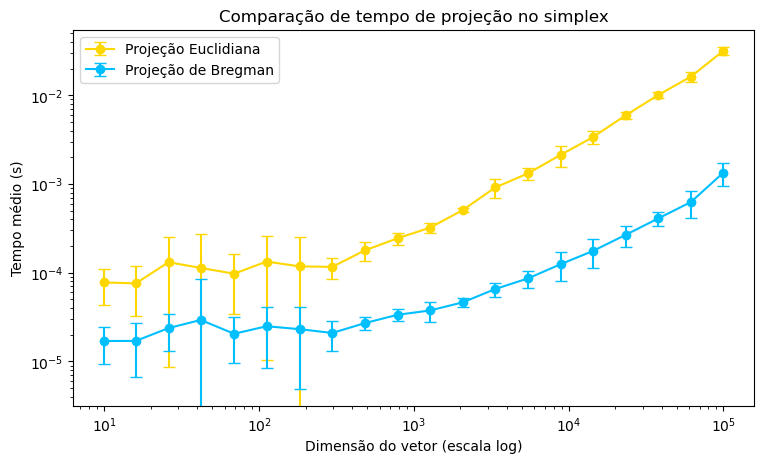

In [15]:
# Plot
plt.figure(figsize=(8,5))
plt.errorbar(dims, mean_times_euclidean, yerr=std_times_euclidean, 
             fmt='o-', color="gold", capsize=4, label="Projeção Euclidiana")
plt.errorbar(dims, mean_times_bregman, yerr=std_times_bregman, 
             fmt='o-', color="deepskyblue", capsize=4, label="Projeção de Bregman")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Dimensão do vetor (escala log)")
plt.ylabel("Tempo médio (s)")
plt.title("Comparação de tempo de projeção no simplex")
plt.legend()
#plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout(pad=2.0)
plt.savefig("imagens_dissertação/comparação_projeções/comparação_projeções_loglog.pdf",
            dpi=300,
            bbox_inches='tight')